In [17]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Literal , Annotated
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage , HumanMessage
import operator


In [18]:
load_dotenv()

True

In [29]:
generator_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7
)
evaluator_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)
optimizer_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.3
)


In [31]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [32]:

structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [42]:
#state
class TweetState(TypedDict):

    topic : str  
    tweet: str 
    evaluation: Literal["approved" , "needs_improvement"]
    feedback:str
    iteration:int
    max_iteration: int

    tweet_history: Annotated[list[str],operator.add]
    feedback_history: Annotated[list[str],operator.add]


In [43]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response , 'tweet_history':[response]}

In [35]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [36]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [37]:
def route_evauluation(state:TweetState):

    if state['evaluation']=='approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else :
        return 'needs_improvement'

In [38]:
graph = StateGraph(TweetState)

graph.add_node('generate' , generate_tweet)
graph.add_node('evaluate' , evaluate_tweet)
graph.add_node('optimize' , optimize_tweet)


graph.add_edge(START , 'generate')
graph.add_edge('generate' , 'evaluate')

graph.add_conditional_edges('evaluate' ,route_evauluation ,{'approved' : END , 'needs_improvement' : 'optimize'})

graph.add_edge('optimize' , 'evaluate')

workflow = graph.compile()

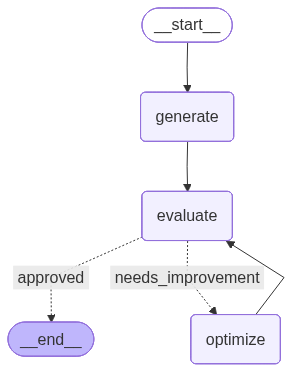

In [39]:
workflow

In [ ]:
initial_state = {
    "topic" : "is AI harmful for Sodtware Developers",
    "iteration" : 1,
    "max_iterations": 5
} 
workflow.invoke(initial_state)

{'topic': 'is AI harmful for Sodtware Developers',
 'tweet': 'Harmful for devs? Nah. AI just means my next PR review will be critiquing *its* code. Pretty sure I can still argue better than a chatbot. 😂',
 'evaluation': 'approved',
 'feedback': 'This tweet effectively tackles a current, relatable topic for developers with a confident and amusing tone. The opening hook, "Harmful for devs? Nah," is sharp and immediately grabs attention, leading into a well-structured thought. It maintains good punchiness, stays well within character limits, and avoids common pitfalls like setup-punchline formats or generic endings. While the humor isn\'t entirely groundbreaking, it resonates with the target audience and has decent virality potential within developer communities, making it a solid and effective tweet.',
 'iteration': 1}

In [ ]:

# testing Done and Desired Outputs acheived 
# completed with Iterative Workflows 